In [115]:
import pandas as pd
pd.set_option('display.max_colwidth', 500)

## Note on Data Availability

The raw transcript (utterance) data is **not included** in this submission due to privacy and confidentiality constraints. 
The CSV files in `./data/` contain LLM classification results with the `utterance` column removed. 
Similarly, the human labeling data in `./human+labeling/` has been anonymized (labeler IDs: P1–P8) with utterance text removed.

To reproduce the full analysis pipeline, users must supply their own transcript data to the Python classification scripts (`llm.py`, `llm_api.py`).

In [116]:
def update_previous_speaker_reference(df):
    df = df.copy()
       
    for i in range(len(df)):
        if (df.loc[i, 'llm_label'] == 'Engage Others Idea' and 
            df.loc[i, 'llm_reference'] == 'Previous Speaker'):
                        
            current_group = df.loc[i, 'group']
            current_date = df.loc[i, 'date']
            current_utterance_id = df.loc[i, 'utterance_id']
            
            prev_utterances = df[
                (df['group'] == current_group) & 
                (df['date'] == current_date) & 
                (df['utterance_id'] < current_utterance_id)
            ]
            
            if len(prev_utterances) > 0:
                prev_speaker = prev_utterances.iloc[-1]['name']
                if prev_speaker == df.loc[i, "name"]:
                    prev_speaker = "none"
                    df.loc[i, 'llm_reference'] = prev_speaker
                else:
                    df.loc[i, 'llm_reference'] = prev_speaker
            else:
                df.loc[i, 'llm_reference'] = "none"   
    
    return df

def update_teacher_related_utterances(df, delete=False):
    df = df.copy()
    indices_to_remove = set()    
    teacher_indices = df[df['name'] == 'T'].index.tolist()
    
    if delete:
        indices_to_remove.update(teacher_indices)
    else:
        df.loc[df['name'] == 'T', 'llm_label'] = 'Uncorrelated'
    
    for i in teacher_indices:
        if i >= len(df):  
            continue
            
        current_group = df.loc[i, 'group']
        current_date = df.loc[i, 'date']
        current_utterance_id = df.loc[i, 'utterance_id']
        
        subsequent_utterances = df[
            (df['group'] == current_group) & 
            (df['date'] == current_date) & 
            (df['utterance_id'] > current_utterance_id)
        ].sort_values('utterance_id')
        
        if len(subsequent_utterances) > 0:
            next_utterance_idx = subsequent_utterances.index[0]
            
            if delete:
                indices_to_remove.add(next_utterance_idx)
            else:                
                df.loc[next_utterance_idx, 'llm_label'] = 'Uncorrelated'
    
    if delete and indices_to_remove:
        df = df.drop(list(indices_to_remove)).reset_index(drop=True)
    
    return df

def get_dataset(path, mod = "llama", logit = False, delete = False):
    data = pd.read_csv(path)
    name_list = set((" ".join(data.group.unique())).split(" ") + ["T"])
    data = data[data.name.isin(name_list)].reset_index(drop=True)

    data.llm_reference = data['llm_reference'].str.replace('**', '')
    data.llm_reference = data['llm_reference'].str.replace('NA', 'none')
    data.llm_reference = data['llm_reference'].str.replace(r'\s*\([^)]*\)', '', regex=True)
    data.name = data['name'].str.replace(r'\s*\([^)]*\)', '', regex=True)
    data.name = data['name'].str.replace('Jullian', 'Julian')
    data.name = data['name'].str.replace('Teacher', 'T')   

    data = update_previous_speaker_reference(data)
    print(f"Previous Speaker references updated")

    data = update_teacher_related_utterances(data, delete)
    print(f"Teacher-related utterances updated to Uncorrelated")

    data = data.sort_values(by=["date","group","block_index"], ascending=[True, True, True]).reset_index(drop=True)
    data['label'] = data['llm_label'].str.lower().fillna('none')
    data['level'] = data['llm_engagement'].str.lower().fillna('none')
    data['reference'] = data['llm_reference'].str.lower().fillna('none')
    data['group'] = data['group'].str.lower()
    data['name'] = data['name'].str.lower()
    data["group_size"] = [len(g.split(" ")) for g in data.group]
# 
    if logit:
        data = data.loc[:,["name","date","timestamp","label","level","reference","group","group_size",
                           "tokprob_explain_own_idea","tokprob_engage_others","tokprob_uncorrelated",
                           "tokprob_engage_low","tokprob_engage_medium","tokprob_engage_high",
                           "prob_explain_own_idea","prob_engage_others_low","prob_engage_others_medium","prob_engage_others_high","prob_uncorrelated"]]
    else:
        data = data.loc[:,["name","date","timestamp","label","level","reference","group","group_size"]]

    data.loc[data['label'] != 'engage others idea', 'level'] = 'none'

    return data

In [117]:
llama_dt = get_dataset("./data/llama_31_results_final_ver2.csv","llama",False,False)
phi_dt = get_dataset("./data/phi4_results_final_ver2.csv","phi",False,False)
qwen_dt = get_dataset("./data/qwen3_results_final_ver2.csv","qwen",False,False)
google_dt = get_dataset("./data/google_api_ver2_system.csv","google",False,False)
google_pro_ver2_dt = get_dataset("./data/google_pro_api_ver2_128_system.csv","google",False,False)
anthropic_dt = get_dataset("./data/anthropic_api_ver2.csv","anthropic",False,False)
openai_dt = get_dataset("./data/openai_api_ver2_cleaned.csv","openai",False,False)

llama_dt["cls"] = [label + "_" + level for label,level in zip(llama_dt.label, llama_dt.level)]
phi_dt["cls"] = [label + "_" + level for label,level in zip(phi_dt.label, phi_dt.level)]
qwen_dt["cls"] = [label + "_" + level for label,level in zip(qwen_dt.label, qwen_dt.level)]
google_dt["cls"] = [label + "_" + level for label,level in zip(google_dt.label, google_dt.level)]
google_pro_ver2_dt["cls"] = [label + "_" + level for label,level in zip(google_pro_ver2_dt.label, google_pro_ver2_dt.level)]
anthropic_dt["cls"] = [label + "_" + level for label,level in zip(anthropic_dt.label, anthropic_dt.level)]
openai_dt["cls"] = [label + "_" + level for label,level in zip(openai_dt.label, openai_dt.level)]

llama_dt.loc[llama_dt.reference == 'j','reference'] = 'julian'
llama_dt.loc[llama_dt.reference == 'peer','reference'] = "delilah"
phi_dt.loc[phi_dt.reference == 'm','reference'] = 'marco'
anthropic_dt.loc[anthropic_dt.reference == 's','reference'] = 'julian'
openai_dt.loc[openai_dt.reference == 's','reference'] = 'julian'
openai_dt.loc[openai_dt.reference == 'm','reference'] = 'marco'
openai_dt.loc[openai_dt.reference == 'group','reference'] = 'esther'
google_pro_ver2_dt.loc[google_pro_ver2_dt.reference == 's','reference'] = 'julian'

Previous Speaker references updated
Teacher-related utterances updated to Uncorrelated
Previous Speaker references updated
Teacher-related utterances updated to Uncorrelated
Previous Speaker references updated
Teacher-related utterances updated to Uncorrelated
Previous Speaker references updated
Teacher-related utterances updated to Uncorrelated
Previous Speaker references updated
Teacher-related utterances updated to Uncorrelated
Previous Speaker references updated
Teacher-related utterances updated to Uncorrelated
Previous Speaker references updated
Teacher-related utterances updated to Uncorrelated


In [118]:
import pandas as pd
import numpy as np
from collections import Counter

def combine_label_and_level(label, level):
    """Combine label and level to create full label."""
    if pd.isna(label) or str(label).strip() == 'none':
        return None
    
    # If level is not none and not empty, add it in parentheses
    if pd.notna(level) and str(level).strip() != 'none' and str(level).strip() != '':
        return f"{label} ({level.upper()})"
    else:
        return label

def calculate_shannon_entropy(labels):
    """
    Calculate Shannon entropy for a list of labels.
    
    For a given utterance with classification probabilities {p_1, p_2, ..., p_n} 
    across n possible labels, entropy H(X) is computed as:
    
    H(X) = -∑(i=1 to n) p_i * log2(p_i)
    
    where p_i = number of models selecting label i / total number of models
    
    Args:
        labels (list): List of labels from different models for the same utterance
        
    Returns:
        float: Shannon entropy (0 = perfect agreement, higher = more disagreement)
    """
    if not labels or len(labels) == 0:
        return 0.0
    
    # Count occurrences of each label
    label_counts = Counter(labels)
    total_models = len(labels)
    
    # Calculate entropy
    entropy = 0.0
    for count in label_counts.values():
        p_i = count / total_models  # Probability of label i
        if p_i > 0:  # Avoid log(0)
            entropy -= p_i * np.log2(p_i)
    
    return entropy

def analyze_llm_uncertainty_with_get_dataset(datasets):
    """
    Analyze inter-model uncertainty for LLM classifications using Shannon entropy.
    Works with datasets processed by get_dataset function.
    
    Args:
        datasets (list): List of dictionaries containing dataset information.
                        Each dict should have keys: 'data' (DataFrame), 'name' (str)
                        Data should be output from get_dataset function.
                        
    Returns:
        pandas.DataFrame: DataFrame with columns:
            - utterance_index: Index-based identifier for each utterance (since utterance_id is removed)
            - entropy: Shannon entropy measuring disagreement among models
            - unique_label_count: Number of unique labels for this utterance
            - total_models: Number of models that provided labels
            - agreement_ratio: Proportion of models agreeing on most frequent label
            - most_frequent_label: The most commonly assigned label
            - {model_name}: Individual model predictions for each model
    """
    
    # Prepare data from each model
    model_data = []
    
    for dataset in datasets:
        df = dataset['data']
        model_name = dataset['name']
        
        print(f"Processing {model_name}...")
        print(f"Available columns: {list(df.columns)}")
        print(f"Data shape: {df.shape}")
        
        # Check required columns exist (after get_dataset processing)
        required_columns = ['label']  # 'level' is optional
        missing_columns = [col for col in required_columns if col not in df.columns]
        
        if missing_columns:
            print(f"Warning: Skipping {model_name} - missing columns: {missing_columns}")
            continue
        
        # Create a copy and add index as utterance identifier
        df_processed = df.copy().reset_index(drop=True)
        df_processed['utterance_index'] = df_processed.index
        
        # Combine label and level to create full label
        if 'level' in df.columns:
            print(f"Processing {model_name}: Combining label and level")
            df_processed['full_label'] = df_processed.apply(
                lambda row: combine_label_and_level(row['label'], row['level']), 
                axis=1
            )
        else:
            print(f"Processing {model_name}: Using label only")
            df_processed['full_label'] = df_processed['label']
        
        # Select relevant columns and clean data
        model_df = df_processed[['utterance_index', 'full_label']].copy()
        model_df = model_df.dropna(subset=['full_label'])
        
        # Remove rows where full_label is None
        model_df = model_df[model_df['full_label'].notna()]
        
        model_df.rename(columns={'full_label': model_name}, inplace=True)
        model_df.set_index('utterance_index', inplace=True)
        
        print(f"Loaded {len(model_df)} valid labels from {model_name}")
        model_data.append(model_df)
    
    if not model_data:
        print("No valid data found to process.")
        return pd.DataFrame()
    
    # Merge all model predictions on utterance_index
    print("Merging data from all models...")
    merged_df = pd.concat(model_data, axis=1)
    print(f"Merged data shape: {merged_df.shape}")
    
    # Calculate uncertainty metrics for each utterance
    results = []
    
    for utterance_index, row in merged_df.iterrows():
        # Get non-null labels for this utterance
        labels = [label for label in row.tolist() if pd.notna(label)]
        
        if not labels:
            continue
        
        # Calculate Shannon entropy
        entropy = calculate_shannon_entropy(labels)
        
        # Calculate additional metrics
        label_counts = Counter(labels)
        unique_labels = len(label_counts)
        total_models = len(labels)
        most_frequent_label = label_counts.most_common(1)[0][0]
        agreement_ratio = label_counts.most_common(1)[0][1] / total_models
        
        # Create result record
        result = {
            'utterance_index': utterance_index,
            'entropy': entropy,
            'unique_label_count': unique_labels,
            'total_models': total_models,
            'agreement_ratio': agreement_ratio,
            'most_frequent_label': most_frequent_label
        }
        
        # Add individual model predictions
        for model_name, label in row.dropna().items():
            result[model_name] = label
            
        results.append(result)
    
    # Convert to DataFrame and sort by utterance_index
    uncertainty_df = pd.DataFrame(results)
    # uncertainty_df = uncertainty_df.sort_values('utterance_index').reset_index(drop=True)
    
    print(f"Analysis complete. Found {len(uncertainty_df)} utterances with labels from multiple models.")
    
    # Print summary statistics
    if not uncertainty_df.empty:
        print(f"Mean entropy: {uncertainty_df['entropy'].mean():.4f}")
        print(f"Max entropy: {uncertainty_df['entropy'].max():.4f}")
        print(f"Min entropy: {uncertainty_df['entropy'].min():.4f}")
        print(f"Utterances with maximum disagreement (entropy > 2.0): {len(uncertainty_df[uncertainty_df['entropy'] > 2.0])}")
        
        # Print label distribution
        print("\nLabel distribution (most frequent labels):")
        label_dist = uncertainty_df['most_frequent_label'].value_counts()
        print(label_dist)
    
    return uncertainty_df

def get_high_uncertainty_utterances(uncertainty_df, entropy_threshold=None, top_n=None):
    """
    Get utterances with high uncertainty based on entropy.
    
    Args:
        uncertainty_df (pd.DataFrame): Output from analyze_llm_uncertainty_with_get_dataset()
        entropy_threshold (float, optional): Minimum entropy threshold
        top_n (int, optional): Number of top uncertain utterances to return
        
    Returns:
        pd.DataFrame: Filtered DataFrame with high uncertainty utterances
    """
    if uncertainty_df.empty:
        return uncertainty_df
    
    # Sort by entropy (descending)
    sorted_df = uncertainty_df.sort_values('entropy', ascending=False)
    
    if entropy_threshold is not None:
        sorted_df = sorted_df[sorted_df['entropy'] >= entropy_threshold]
    
    if top_n is not None:
        sorted_df = sorted_df.head(top_n)
    
    return sorted_df


datasets = [
    {'data': google_dt, 'name': 'Gemini-2.5-flash'},
    {'data': google_pro_ver2_dt, 'name': 'Gemini-2.5-pro'},
    {'data': anthropic_dt, 'name': 'Claude4-sonnet'},
    {'data': openai_dt, 'name': 'Gpt4.1'},
    {'data': llama_dt, 'name': 'Llama3.1-8B'},
    {'data': phi_dt, 'name': 'Phi4-14B'},
    {'data': qwen_dt, 'name': 'Qwen3-32B-AWQ'}
]

uncertainty_results = analyze_llm_uncertainty_with_get_dataset(datasets)

print("\nTop 20 most uncertain utterances:")
high_uncertainty = get_high_uncertainty_utterances(uncertainty_results, top_n=20)
print(high_uncertainty[['utterance_index', 'entropy', 'unique_label_count', 'most_frequent_label', 'agreement_ratio']])

high_entropy = get_high_uncertainty_utterances(uncertainty_results, entropy_threshold=1.5)
print(f"\nUtterances with entropy > 1.5: {len(high_entropy)}")

Processing Gemini-2.5-flash...
Available columns: ['name', 'date', 'timestamp', 'label', 'level', 'reference', 'group', 'group_size', 'cls']
Data shape: (4233, 9)
Processing Gemini-2.5-flash: Combining label and level
Loaded 4233 valid labels from Gemini-2.5-flash
Processing Gemini-2.5-pro...
Available columns: ['name', 'date', 'timestamp', 'label', 'level', 'reference', 'group', 'group_size', 'cls']
Data shape: (4233, 9)
Processing Gemini-2.5-pro: Combining label and level
Loaded 4233 valid labels from Gemini-2.5-pro
Processing Claude4-sonnet...
Available columns: ['name', 'date', 'timestamp', 'label', 'level', 'reference', 'group', 'group_size', 'cls']
Data shape: (4233, 9)
Processing Claude4-sonnet: Combining label and level
Loaded 4233 valid labels from Claude4-sonnet
Processing Gpt4.1...
Available columns: ['name', 'date', 'timestamp', 'label', 'level', 'reference', 'group', 'group_size', 'cls']
Data shape: (4233, 9)
Processing Gpt4.1: Combining label and level
Loaded 4233 valid l

In [119]:
import pandas as pd

label_replacement_map = {
    'uncorrelated': 'uncorrelated_none',
    'explain own idea': 'explain own idea_none',
    'engage others idea (LOW)': 'engage others idea_low',
    'engage others idea (MEDIUM)': 'engage others idea_medium',
    'engage others idea (HIGH)': 'engage others idea_high'
}

uncertainty_results['cls'] = uncertainty_results['most_frequent_label'].replace(label_replacement_map)

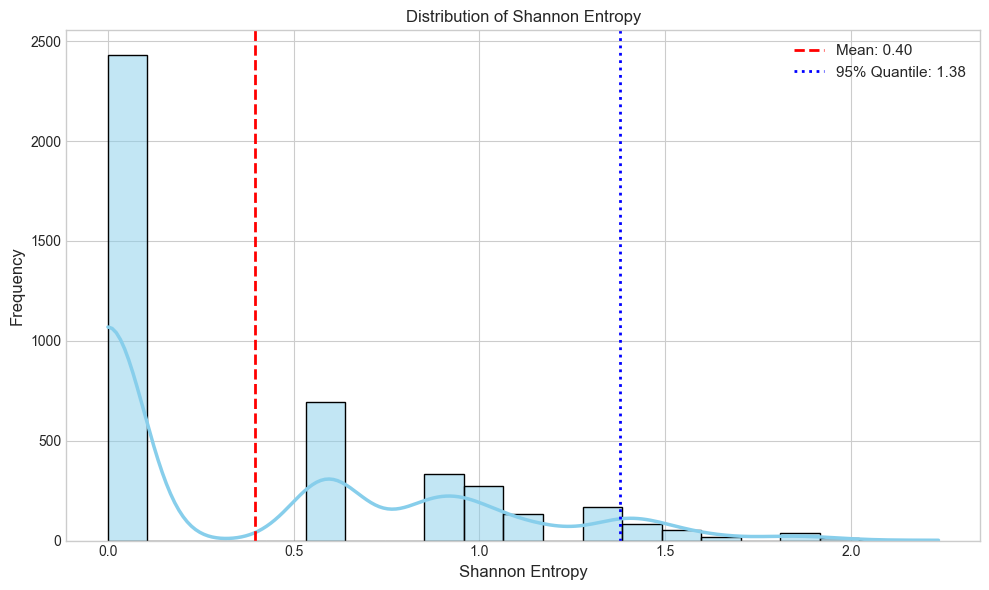

In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_entropy_histogram(df, column_name='entropy', output_filename='entropy_distribution_formal.png'):
    
    if column_name not in df.columns:
        print(f"Error: '{column_name}' not found")
        return

    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rc('axes', labelsize=12)    
    plt.rc('xtick', labelsize=10)   
    plt.rc('ytick', labelsize=10)   
    plt.rc('legend', fontsize=11)   
    plt.rc('figure', titlesize=14)  

    fig, ax = plt.subplots(figsize=(10, 6))

    sns.histplot(data=df, x=column_name, kde=True, ax=ax,
                 line_kws={'linewidth': 2.5, 'color': 'navy'},
                 color='skyblue',   
                 edgecolor='black') 

    mean_val = df[column_name].mean()
    quantile_val = df[column_name].quantile(0.95)

    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    ax.axvline(quantile_val, color='blue', linestyle=':', linewidth=2, label=f'95% Quantile: {quantile_val:.2f}')

    ax.set_title('Distribution of Shannon Entropy')
    ax.set_xlabel('Shannon Entropy')
    ax.set_ylabel('Frequency')

    ax.legend()
    plt.tight_layout()
    plt.show()

plot_entropy_histogram(uncertainty_results)


In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from sklearn.metrics import cohen_kappa_score

label_column = 'label'

def calc_cohens_kappa(df1, df2, label_column):
    labels1 = df1[label_column]
    labels2 = df2[label_column]
    
    if len(labels1) != len(labels2):
        raise ValueError("The lengths of the two dataframes are different.")
    
    valid_mask = pd.notna(labels1) & pd.notna(labels2)
    labels1_clean = labels1[valid_mask]
    labels2_clean = labels2[valid_mask]
    
    if len(labels1_clean) == 0:
        raise ValueError("Invalid data")
    
    kappa_value = cohen_kappa_score(labels1_clean, labels2_clean)
    return kappa_value

def create_kappa_matrix(df_list, label_column='label', mlist=None):
    n_participants = len(df_list)
    kappa_matrix = np.full((n_participants, n_participants), np.nan)
    np.fill_diagonal(kappa_matrix, 1.0)
    
    for i, j in combinations(range(n_participants), 2):
        try:
            kappa_value = calc_cohens_kappa(df_list[i], df_list[j], label_column)
            kappa_matrix[i, j] = kappa_value
            kappa_matrix[j, i] = kappa_value
            participant_i = mlist[i] if mlist else f"Participant_{i}"
            participant_j = mlist[j] if mlist else f"Participant_{j}"
            print(f"{participant_i} vs {participant_j}: {kappa_value:.4f}")
        except Exception as e:
            participant_i = mlist[i] if mlist else f"Participant_{i}"
            participant_j = mlist[j] if mlist else f"Participant_{j}"
            print(f"{participant_i} vs {participant_j}: Error - {e}")
            kappa_matrix[i, j] = np.nan
            kappa_matrix[j, i] = np.nan
    
    if mlist:
        participant_labels = [f'{mlist[i]}' for i in range(n_participants)]
    else:
        participant_labels = [f'Participant_{i}' for i in range(n_participants)]
    
    kappa_df = pd.DataFrame(kappa_matrix, 
                           index=participant_labels, 
                           columns=participant_labels)
    
    return kappa_df

def plot_kappa_matrix(kappa_df, title="Pairwise Cohen's Kappa Agreement Matrix"):
    plt.figure(figsize=(10, 8))
    
    mask = np.isnan(kappa_df.values) 
    
    sns.heatmap(kappa_df, 
                annot=True,          
                fmt='.3f',           
                cmap='RdYlBu_r',     
                center=0.5,          
                vmin=0, vmax=1,      
                square=True,         
                cbar_kws={'label': "Cohen's Kappa"},
                mask=mask)           
    
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel('LLMs', fontsize=12)
    plt.ylabel('LLMs', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    return plt.gcf()

def analyze_kappa_matrix(kappa_df):
    participant_means = {}
    for participant in kappa_df.index:
        others = kappa_df.loc[participant].drop(participant)
        mean_kappa = others.mean()
        participant_means[participant] = mean_kappa
        print(f"{participant}: {mean_kappa:.3f}")
    
    pairs = []
    for i in range(len(kappa_df)):
        for j in range(i+1, len(kappa_df)):
            value = kappa_df.iloc[i, j]
            if not np.isnan(value):
                pairs.append((kappa_df.index[i], kappa_df.columns[j], value))
    
    pairs_sorted = sorted(pairs, key=lambda x: x[2], reverse=True)
    for p1, p2, kappa in pairs_sorted[:5]:
        print(f"{p1} vs {p2}: {kappa:.3f}")
    
    for p1, p2, kappa in pairs_sorted[-5:]:
        print(f"{p1} vs {p2}: {kappa:.3f}")
    
    print("\n=== Agreement distribution ===")
    all_values = [kappa for _, _, kappa in pairs]
    excellent = sum(1 for k in all_values if k > 0.8)
    good = sum(1 for k in all_values if 0.6 < k <= 0.8)
    moderate = sum(1 for k in all_values if 0.4 < k <= 0.6)
    fair = sum(1 for k in all_values if 0.2 < k <= 0.4)
    poor = sum(1 for k in all_values if k <= 0.2)
    
    print(f"Excellent (>0.8): {excellent} pairs")
    print(f"Good (0.6-0.8): {good} pairs")
    print(f"Moderate (0.4-0.6): {moderate} pairs")
    print(f"Fair (0.2-0.4): {fair} pairs")
    print(f"Poor (≤0.2): {poor} pairs")
    
    return participant_means, pairs_sorted

llama3.1 vs qwen3: 0.4874
llama3.1 vs phi4: 0.5511
llama3.1 vs gpt-4.1: 0.4800
llama3.1 vs cluade-4.0-sonnet: 0.4841
llama3.1 vs gemini-2.5-flash: 0.4947
llama3.1 vs gemini-2.5-pro: 0.4426
qwen3 vs phi4: 0.5683
qwen3 vs gpt-4.1: 0.5999
qwen3 vs cluade-4.0-sonnet: 0.6193
qwen3 vs gemini-2.5-flash: 0.6019
qwen3 vs gemini-2.5-pro: 0.5567
phi4 vs gpt-4.1: 0.6351
phi4 vs cluade-4.0-sonnet: 0.6297
phi4 vs gemini-2.5-flash: 0.6315
phi4 vs gemini-2.5-pro: 0.6007
gpt-4.1 vs cluade-4.0-sonnet: 0.6570
gpt-4.1 vs gemini-2.5-flash: 0.6841
gpt-4.1 vs gemini-2.5-pro: 0.6437
cluade-4.0-sonnet vs gemini-2.5-flash: 0.7103
cluade-4.0-sonnet vs gemini-2.5-pro: 0.7001
gemini-2.5-flash vs gemini-2.5-pro: 0.7000


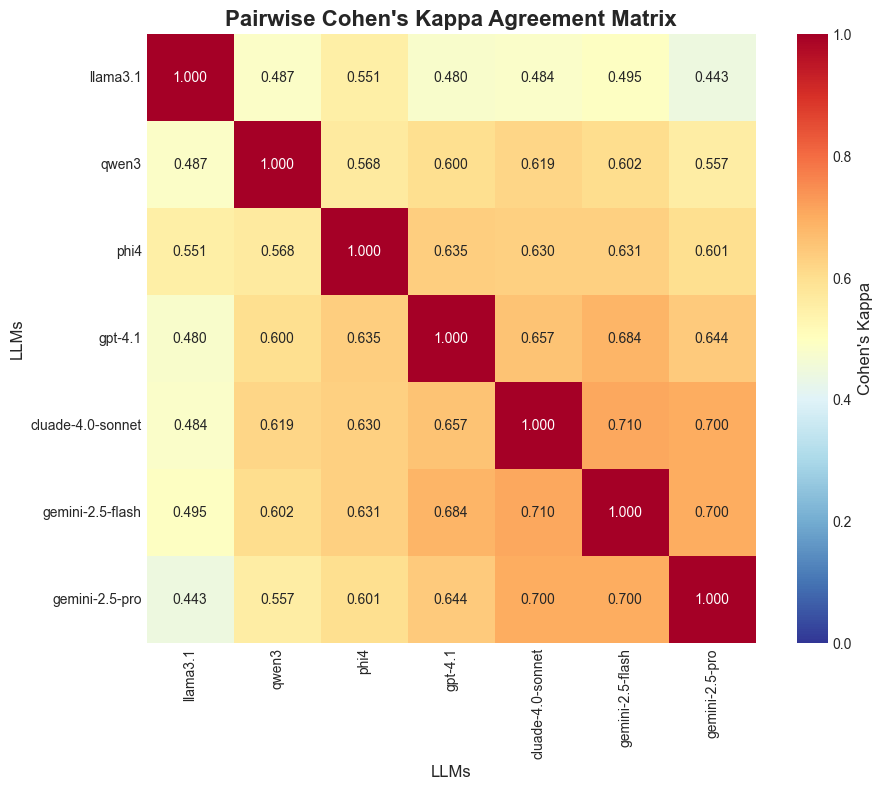

llama3.1: 0.490
qwen3: 0.572
phi4: 0.603
gpt-4.1: 0.617
cluade-4.0-sonnet: 0.633
gemini-2.5-flash: 0.637
gemini-2.5-pro: 0.607
cluade-4.0-sonnet vs gemini-2.5-flash: 0.710
cluade-4.0-sonnet vs gemini-2.5-pro: 0.700
gemini-2.5-flash vs gemini-2.5-pro: 0.700
gpt-4.1 vs gemini-2.5-flash: 0.684
gpt-4.1 vs cluade-4.0-sonnet: 0.657
llama3.1 vs gemini-2.5-flash: 0.495
llama3.1 vs qwen3: 0.487
llama3.1 vs cluade-4.0-sonnet: 0.484
llama3.1 vs gpt-4.1: 0.480
llama3.1 vs gemini-2.5-pro: 0.443

=== Agreement distribution ===
Excellent (>0.8): 0 pairs
Good (0.6-0.8): 12 pairs
Moderate (0.4-0.6): 9 pairs
Fair (0.2-0.4): 0 pairs
Poor (≤0.2): 0 pairs


<Figure size 640x480 with 0 Axes>

In [122]:
mlist = ["llama3.1","qwen3","phi4","gpt-4.1","cluade-4.0-sonnet","gemini-2.5-flash","gemini-2.5-pro"]
kappa_matrix_df = create_kappa_matrix([llama_dt, qwen_dt, phi_dt, openai_dt, anthropic_dt, google_dt, google_pro_ver2_dt], 'cls', mlist)
plot_kappa_matrix(kappa_matrix_df)
participant_means, ranked_pairs = analyze_kappa_matrix(kappa_matrix_df)

In [123]:
import numpy as np
import pandas as pd
from statsmodels.stats.inter_rater import fleiss_kappa

label_column = 'label'  

def calc_fleiss_kappa(df_list, label_column):
    label_series = [df[label_column] for df in df_list]
    all_labels = set()
    for series in label_series:
        all_labels.update(series.dropna().unique())
    all_labels = sorted(list(all_labels))

    num_samples = len(df_list[0])
    num_labels = len(all_labels)
    counts_matrix = np.zeros((num_samples, num_labels), dtype=int)

    label_to_idx = {label: i for i, label in enumerate(all_labels)}

    for sample_idx in range(num_samples):
        for df in df_list:
            label = df[label_column].iloc[sample_idx]
            if pd.notna(label) and label in label_to_idx:
                counts_matrix[sample_idx, label_to_idx[label]] += 1

    kappa_value = fleiss_kappa(counts_matrix, method='fleiss')
    return kappa_value

In [124]:
df_list = [llama_dt, qwen_dt, phi_dt, openai_dt, anthropic_dt, google_dt, google_pro_ver2_dt]
kappa_value = calc_fleiss_kappa(df_list, 'label')
print(f"Fleiss' Kappa: {kappa_value:.4f}")

df_list = [llama_dt, qwen_dt, phi_dt]
kappa_value = calc_fleiss_kappa(df_list, 'label')
print(f"Fleiss' Kappa: {kappa_value:.4f}")

df_list = [openai_dt, anthropic_dt, google_dt, google_pro_ver2_dt]
kappa_value = calc_fleiss_kappa(df_list, 'label')
print(f"Fleiss' Kappa: {kappa_value:.4f}")

Fleiss' Kappa: 0.6575
Fleiss' Kappa: 0.6033
Fleiss' Kappa: 0.7354


In [125]:
from collections import Counter
import pandas as pd

def ensemble_classification(dataframes_list):
    base_df = dataframes_list[0].copy()
    cls_columns = []
    ref_columns = []
    
    for i, df in enumerate(dataframes_list):
        col_name = f'cls_model_{i+1}'
        ref_col = f'ref_model_{i+1}'
        base_df[col_name] = df['cls']
        base_df[ref_col] = df['reference']
        cls_columns.append(col_name)
        ref_columns.append(ref_col)
        
    base_df['final_cls'] = base_df[cls_columns].apply(
        lambda row: ensemble_vote(row.tolist()), axis=1
    )
    
    # reference ensemble
    base_df['reference'] = base_df.apply(
        lambda row: ensemble_reference(
            row['final_cls'],
            [row[col] for col in ref_columns]
        ),
        axis=1
    )
        
    base_df = base_df.drop(columns=cls_columns + ref_columns)
    
    return base_df

def ensemble_vote(cls_values):
    valid_values = [val for val in cls_values if pd.notna(val) and str(val).strip()]
    
    if not valid_values:
        return 'uncorrelated_none'  
    
    counter = Counter(valid_values)
    most_common = counter.most_common()
    total_votes = len(valid_values)
    
    if most_common[0][1] > total_votes / 2:
        return most_common[0][0]
    
    max_count = most_common[0][1]
    tied_labels = [label for label, count in most_common if count == max_count]
    
    if len(tied_labels) == 1:
        return tied_labels[0]
    
    base_labels = [cls.split('_')[0] for cls in valid_values]
    if all(label == 'engage others idea' for label in base_labels):
        engage_tied = [label for label in tied_labels if label.startswith('engage others idea')]
        if engage_tied:
            level_priority = {'low': 1, 'medium': 2, 'high': 3}
            engage_tied.sort(key=lambda x: level_priority.get(x.split('_')[-1], 999))
            return engage_tied[0]
        return 'engage others idea_low'

    api_votes = [val for val in cls_values[:4] if pd.notna(val) and str(val).strip()]
    if not api_votes:
        return valid_values[0]
    
    api_counter = Counter(api_votes)
    return api_counter.most_common(1)[0][0]

def ensemble_reference(final_cls, reference_values):
    if final_cls.startswith('engage others idea'):
        non_empty_refs = [
            ref for ref in reference_values 
            if pd.notnull(ref) and str(ref).strip() and str(ref).strip().lower() != 'none'
        ]
        
        if non_empty_refs:
            counter = Counter(non_empty_refs)
            return counter.most_common(1)[0][0]
        else:
            return None
    else:
        return None

def update_label_level_from_final_cls(df):
    df = df.copy()
    df['final_cls'] = df['final_cls'].fillna('uncorrelated_none')
    
    def safe_split(cls_value):
        if pd.isna(cls_value) or not str(cls_value).strip():
            return 'uncorrelated', 'none'
        
        cls_str = str(cls_value)
        if '_' in cls_str:
            parts = cls_str.rsplit('_', 1)
            return parts[0], parts[1]
        else:
            return cls_str, 'none'
    
    split_result = df['final_cls'].apply(safe_split)
    df['label'] = split_result.apply(lambda x: x[0])
    df['level'] = split_result.apply(lambda x: x[1])
    
    df['cls'] = df['final_cls']
    df = df.drop(columns=['final_cls'])
    
    return df

def find_no_majority_indices(dataframes_list):
    
    all_cls_values = []
    for i in range(len(dataframes_list[0])):
        row_cls_values = [df.iloc[i]['cls'] for df in dataframes_list]
        valid_values = [val for val in row_cls_values if pd.notna(val) and str(val).strip()]
        all_cls_values.append(valid_values)
    
    no_majority_indices = []
    
    for idx, cls_values in enumerate(all_cls_values):
        if not cls_values:
            continue
            
        counter = Counter(cls_values)
        most_common = counter.most_common()
        total_votes = len(cls_values)
        
        has_majority = most_common[0][1] > total_votes / 2
        
        if not has_majority:
            max_count = most_common[0][1]
            tied_count = sum(1 for label, count in most_common if count == max_count)
            
            if tied_count > 1:
                base_labels = [cls.split('_')[0] for cls in cls_values]
                all_engage_others = all(label == 'engage others idea' for label in base_labels)
                
                if not all_engage_others:
                    no_majority_indices.append(idx)
    
    return no_majority_indices


In [126]:
# Check dataframe structure
dataframes = [google_pro_ver2_dt, openai_dt, anthropic_dt, google_dt, llama_dt, phi_dt, qwen_dt]
for i, df in enumerate(dataframes):
    print(f"Model {i+1} ({['google_pro_ver2', 'openai', 'anthropic', 'google', 'llama', 'phi', 'qwen'][i]}):")
    print(f"  Shape: {df.shape}")
    print(f"  Columns: {list(df.columns)}")
    if 'cls' in df.columns:
        print(f"  cls sample: {df['cls'].head(3).tolist()}")
        print(f"  unique cls: {df['cls'].nunique()}")
    print()

final_result = ensemble_classification(dataframes)
final_df = update_label_level_from_final_cls(final_result)

print(final_df['cls'].value_counts())
print(final_df['label'].value_counts())
print(final_df['level'].value_counts())

Model 1 (google_pro_ver2):
  Shape: (4233, 9)
  Columns: ['name', 'date', 'timestamp', 'label', 'level', 'reference', 'group', 'group_size', 'cls']
  cls sample: ['uncorrelated_none', 'engage others idea_high', 'uncorrelated_none']
  unique cls: 5

Model 2 (openai):
  Shape: (4233, 9)
  Columns: ['name', 'date', 'timestamp', 'label', 'level', 'reference', 'group', 'group_size', 'cls']
  cls sample: ['uncorrelated_none', 'engage others idea_medium', 'uncorrelated_none']
  unique cls: 5

Model 3 (anthropic):
  Shape: (4233, 9)
  Columns: ['name', 'date', 'timestamp', 'label', 'level', 'reference', 'group', 'group_size', 'cls']
  cls sample: ['uncorrelated_none', 'engage others idea_high', 'uncorrelated_none']
  unique cls: 5

Model 4 (google):
  Shape: (4233, 9)
  Columns: ['name', 'date', 'timestamp', 'label', 'level', 'reference', 'group', 'group_size', 'cls']
  cls sample: ['uncorrelated_none', 'engage others idea_high', 'uncorrelated_none']
  unique cls: 5

Model 5 (llama):
  Shape: 

In [127]:
dataframes = [google_dt, google_pro_ver2_dt, openai_dt, anthropic_dt, phi_dt, qwen_dt, llama_dt]
final_result = ensemble_classification(dataframes)
final_df = update_label_level_from_final_cls(final_result)

In [128]:
llama_dt.cls.value_counts()

cls
uncorrelated_none            2531
engage others idea_low       1025
explain own idea_none         585
engage others idea_medium      54
engage others idea_high        38
Name: count, dtype: int64

In [129]:
phi_dt.cls.value_counts()

cls
uncorrelated_none            2776
engage others idea_low        550
explain own idea_none         501
engage others idea_medium     281
engage others idea_high       125
Name: count, dtype: int64

In [130]:
qwen_dt.cls.value_counts()

cls
uncorrelated_none            3243
explain own idea_none         416
engage others idea_low        398
engage others idea_high        88
engage others idea_medium      88
Name: count, dtype: int64

In [131]:
google_dt.cls.value_counts()

cls
uncorrelated_none            2979
explain own idea_none         520
engage others idea_low        380
engage others idea_medium     238
engage others idea_high       116
Name: count, dtype: int64

In [132]:
google_pro_ver2_dt.cls.value_counts()

cls
uncorrelated_none            2980
explain own idea_none         499
engage others idea_low        266
engage others idea_medium     256
engage others idea_high       232
Name: count, dtype: int64

In [133]:
anthropic_dt.cls.value_counts()

cls
uncorrelated_none            3097
explain own idea_none         520
engage others idea_low        316
engage others idea_medium     224
engage others idea_high        76
Name: count, dtype: int64

In [134]:
final_df.cls.value_counts()

cls
uncorrelated_none            3040
explain own idea_none         497
engage others idea_low        388
engage others idea_medium     205
engage others idea_high       103
Name: count, dtype: int64

In [135]:
data = final_df.copy()
name_list = set(" ".join(data['group'].unique()).split(" "))
mask = data['label'] == "engage others idea"
new_refs = data.loc[mask, 'reference'].apply(
    lambda r: "Previous Speaker" if r not in name_list else r
)
data.loc[mask, 'reference'] = new_refs
data = data.reset_index()
data.reference.unique()

array([None, 'daniel', 'armando', 'kevin', 'gio', 'keila', 'delilah',
       'angelina', 'maria', 'natalie', 'kimberly', 'william', 'julian',
       'diego', 'shreen', 'isabel', 'esther', 'melissa', 'jessica', 'mya',
       'ruben', 'marco', 'samantha', 'Previous Speaker'], dtype=object)

In [136]:
for i in range(len(data)):
    if (data.loc[i, 'label'] == 'engage others idea' and 
        data.loc[i, 'reference'] == 'Previous Speaker'):
        
        current_group = data.loc[i, 'group']
        current_date = data.loc[i, 'date']
        current_utterance_id = data.loc[i, 'index']
        
        prev_utterances = data[
            (data['group'] == current_group) & 
            (data['date'] == current_date) & 
            (data['index'] < current_utterance_id)
        ]
        
        if len(prev_utterances) > 0:
            prev_speaker = prev_utterances.iloc[-1]['name']
            if(prev_speaker == data.loc[i,"name"]):
                prev_speaker = "none"
            data.loc[i, 'reference'] = prev_speaker

# data.to_csv("../DATA/AL_Full.csv", index=False)

In [137]:
data.iloc[434:445,:]

,index,name,date,timestamp,label,level,reference,group,group_size,cls
434,434,natalie,1.22,0:00,explain own idea,none,None,samantha natalie kimberly,3,explain own idea_none
435,435,kimberly,1.22,0:00,engage others idea,low,natalie,samantha natalie kimberly,3,engage others idea_low
436,436,natalie,1.22,0:00,explain own idea,none,None,samantha natalie kimberly,3,explain own idea_none
437,437,kimberly,1.22,0:00,uncorrelated,none,None,samantha natalie kimberly,3,uncorrelated_none
438,438,samantha,1.22,0:00,explain own idea,none,None,samantha natalie kimberly,3,explain own idea_none
439,439,kimberly,1.22,0:00,explain own idea,none,None,samantha natalie kimberly,3,explain own idea_none
440,440,natalie,1.22,0:00,engage others idea,medium,kimberly,samantha natalie kimberly,3,engage others idea_medium
441,441,kimberly,1.22,0:00,explain own idea,none,None,samantha natalie kimberly,3,explain own idea_none
442,442,natalie,1.22,0:00,uncorrelated,none,None,samantha natalie kimberly,3,uncorrelated_none
443,443,kimberly,1.22,0:00,explain own idea,none,None,samantha natalie kimberly,3,explain own idea_none


In [138]:
data.iloc[260:269,:] 

,index,name,date,timestamp,label,level,reference,group,group_size,cls
260,260,delilah,1.22,2:49,explain own idea,none,None,keila delilah,2,explain own idea_none
261,261,keila,1.22,2:49,uncorrelated,none,None,keila delilah,2,uncorrelated_none
262,262,delilah,1.22,2:49,uncorrelated,none,None,keila delilah,2,uncorrelated_none
263,263,keila,1.22,2:49,engage others idea,medium,delilah,keila delilah,2,engage others idea_medium
264,264,delilah,1.22,2:49,uncorrelated,none,None,keila delilah,2,uncorrelated_none
265,265,keila,1.22,2:49,uncorrelated,none,None,keila delilah,2,uncorrelated_none
266,266,delilah,1.22,2:49,uncorrelated,none,None,keila delilah,2,uncorrelated_none
267,267,keila,1.22,2:49,engage others idea,low,delilah,keila delilah,2,engage others idea_low
268,268,delilah,1.22,2:49,uncorrelated,none,None,keila delilah,2,uncorrelated_none


In [139]:
data.iloc[554:557,:] # Table 3

,index,name,date,timestamp,label,level,reference,group,group_size,cls
554,554,william,1.22,1:19,uncorrelated,none,None,william julian,2,uncorrelated_none
555,555,julian,1.22,1:19,engage others idea,high,william,william julian,2,engage others idea_high
556,556,william,1.22,1:19,engage others idea,medium,julian,william julian,2,engage others idea_medium


In [140]:
data.iloc[489:503,:] # Table 4

,index,name,date,timestamp,label,level,reference,group,group_size,cls
489,489,natalie,1.22,10:53,uncorrelated,none,None,samantha natalie kimberly,3,uncorrelated_none
490,490,kimberly,1.22,10:53,uncorrelated,none,None,samantha natalie kimberly,3,uncorrelated_none
491,491,natalie,1.22,10:53,uncorrelated,none,None,samantha natalie kimberly,3,uncorrelated_none
492,492,kimberly,1.22,10:53,engage others idea,medium,natalie,samantha natalie kimberly,3,engage others idea_medium
493,493,natalie,1.22,10:53,explain own idea,none,None,samantha natalie kimberly,3,explain own idea_none
494,494,kimberly,1.22,10:53,engage others idea,low,natalie,samantha natalie kimberly,3,engage others idea_low
495,495,natalie,1.22,10:53,explain own idea,none,None,samantha natalie kimberly,3,explain own idea_none
496,496,kimberly,1.22,10:53,uncorrelated,none,None,samantha natalie kimberly,3,uncorrelated_none
497,497,natalie,1.22,10:53,uncorrelated,none,None,samantha natalie kimberly,3,uncorrelated_none
498,498,kimberly,1.22,10:53,uncorrelated,none,None,samantha natalie kimberly,3,uncorrelated_none


In [141]:
data_uncorr = data[(data.label.str.contains("engag|contributing")==False)&(data.label.str.contains("own")==False)]
data = data[~data.label.str.contains("uncorr")]

In [142]:
data_EOI = data[(data.label.str.contains("engag|contributing")==True)&(data.level.str.contains("own")==False)]
data_EXP = data[(data.label.str.contains("engag|contributing")==False)&(data.label.str.contains("own")==True)]

In [143]:
import re
def compress_2d_to_1d(lst):
    result = []
    for inner_list in lst:
        result.extend(inner_list)
    return result

data_EOI.loc[:,"level"] = ["medium" if "medium" in l else l for l in data_EOI.level]
data_EOI.loc[:,"level"] = ["low" if "low" in l else l for l in data_EOI.level]
data_EOI.loc[:,"level"] = ["high" if "high" in l else l for l in data_EOI.level]
levels = compress_2d_to_1d([re.findall(r'\(([^)]+)',t) for t in data_EOI[data_EOI.level == "none"].label])
data_EOI.loc[data_EOI.level == "none","level"] = levels

In [144]:
data_EOI = data_EOI[data_EOI.level.str.contains("low|medium|high")==True]
data_EOI = data_EOI.rename(columns = {'reference':'ref'})
data_EXP = data_EXP.rename(columns = {'reference':'ref'})
data_uncorr = data_uncorr.rename(columns = {'reference':'ref'})
data_EXP.loc[:,"ref"] = [g.replace(n,"").strip() for g,n in zip(data_EXP.group, data_EXP.name)]
data_EOI = data_EOI[data_EOI.ref != 't'].reset_index(drop=True)

In [145]:
len(data_uncorr)

3040

In [146]:
len(data_EXP)

497

In [147]:
len(data_EOI)

696

In [148]:
data_EXP.ref = [r.replace("  "," ") for r in data_EXP.ref]
data_EOI.ref = [r.replace("  "," ") for r in data_EOI.ref]

data_EOI = data_EOI[data_EOI.ref != "none"]

data_EXP = data_EXP[data_EXP.name != 't'].reset_index(drop=True)
data_EOI = data_EOI[data_EOI.name != 't'].reset_index(drop=True)

In [149]:
pd.crosstab(data_EOI.level,data_EOI.level)

level,high,low,medium
level,,,
high,103,0,0
low,0,388,0
medium,0,0,205


In [150]:
data_EOI.name.unique()

array(['armando', 'daniel', 'gio', 'kevin', 'diego', 'keila', 'delilah',
       'maria', 'angelina', 'kimberly', 'natalie', 'samantha', 'julian',
       'william', 'shreen', 'isabel', 'melissa', 'esther', 'mya',
       'jessica', 'marco', 'ruben'], dtype=object)

In [151]:
data_EOI.ref.unique()

array(['daniel', 'armando', 'kevin', 'gio', 'keila', 'delilah',
       'angelina', 'maria', 'natalie', 'kimberly', 'william', 'julian',
       'diego', 'shreen', 'isabel', 'esther', 'melissa', 'jessica', 'mya',
       'ruben', 'marco', 'samantha', 'Previous Speaker'], dtype=object)

In [152]:
# AL
# data_EOI.reset_index(drop=True).to_csv("../DATA/EOI_AL.csv",index=False)
# data_EXP.reset_index(drop=True).to_csv("../DATA/EXP_AL.csv",index=False)